# NB05 - Regularización L1 (Lasso)

**Objetivos de aprendizaje**

- Definir el penalti L1 y contrastarlo con L2.
- Entender por qué L1 puede producir coeficientes exactamente cero.
- Usar Lasso logístico para selección automática de variables.
- Visualizar rutas de coeficientes y tablas de sparsity.
- Comparar fronteras de decisión en dos dimensiones.

En todo el notebook mantenemos la convención global del repositorio: `virginica = 1` es la clase positiva y `versicolor = 0` es la clase negativa.

**Referencias de este notebook**

- Tibshirani (1996): introduce Lasso como encogimiento y selección simultáneos.
- Hastie, Tibshirani & Friedman (2009): explican la geometría L1 y sus diferencias frente a L2.


In [1]:
%matplotlib inline
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('png')
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

# Los notebooks pueden ejecutarse desde la raiz del repo o desde notebooks/.
# Este bloque localiza la raiz y agrega src/ al path de importacion.
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from utils import (
    COLOR_PALETTE,
    RANDOM_STATE,
    get_train_test_split,
    load_binary_iris,
    load_processed_splits,
    plot_coefficients,
    plot_decision_boundary,
    plot_regularization_path,
    plot_sigmoid,
    save_processed_splits,
    set_plot_style,
)

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
set_plot_style()
np.random.seed(RANDOM_STATE)

DATA_DIR = PROJECT_ROOT / "data" / "processed"

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler


## 1. Penalti L1 y geometría de sparsity

Lasso agrega `lambda * ||beta||_1`. La región L1 tiene esquinas; cuando la solución toca una esquina, algunos coeficientes quedan exactamente en cero. Esa es la diferencia geométrica que Tibshirani (1996) explotó para seleccionar variables.


In [2]:
data = load_processed_splits(DATA_DIR)
X_train = data["X_train"]
X_train_scaled = data["X_train_scaled"]
y_train = data["y_train"]
feature_names = data["feature_names"]


## 2. Implementación con scikit-learn

**Hiperparámetros de Lasso.** `C_values=np.logspace(-2, 2, 14)` explora cuatro órdenes de magnitud: con `C` pequeño la penalización L1 es fuerte y aparecen más ceros; con `C` grande la penalización es débil y sobreviven más variables. `solver='liblinear'` soporta L1 binario de forma estable en datasets pequeños; `max_iter=5000` da margen para converger. El umbral `1e-8` solo decide si un coeficiente numéricamente minúsculo cuenta como cero.


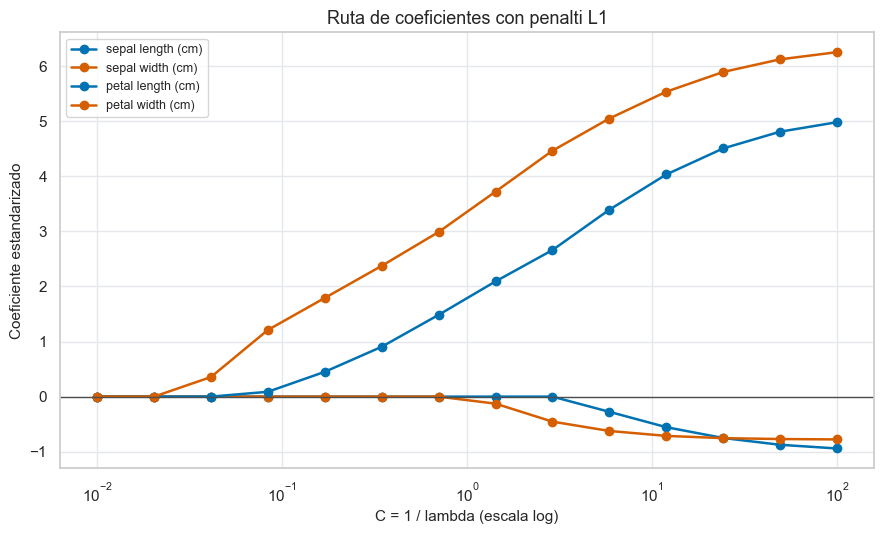

In [3]:
# C va de 0.01 a 100: de L1 fuerte (más ceros) a L1 débil (menos ceros).
C_values = np.logspace(-2, 2, 14)
coefs_l1 = []
sparsity_rows = []

for C in C_values:
    # liblinear soporta L1 en problemas binarios y es estable para este dataset pequeño.
    # C pequeño implica mayor penalización y, por tanto, más coeficientes exactamente cero.
    model = LogisticRegression(
        penalty="l1",
        C=C,
        solver="liblinear",
        max_iter=5000,
        random_state=RANDOM_STATE,
    )
    model.fit(X_train_scaled, y_train)
    coef = model.coef_.ravel()
    coefs_l1.append(coef)

    surviving = [name for name, value in zip(feature_names, coef) if abs(value) > 1e-8]
    sparsity_rows.append(
        {
            "C": C,
            "n_features_no_cero": len(surviving),
            "features_sobrevivientes": ", ".join(surviving) if surviving else "(ninguna)",
        }
    )

coefs_l1 = np.vstack(coefs_l1)
plot_regularization_path(C_values, coefs_l1, feature_names, "Ruta de coeficientes con penalti L1")
plt.show()


**Interpretación.** A diferencia de Ridge, Lasso apaga variables por completo cuando la penalización es fuerte. Esta sparsity puede mejorar interpretabilidad, aunque también puede ser inestable si hay variables muy correlacionadas.


## 3. Tabla de variables sobrevivientes


In [4]:
sparsity_table = pd.DataFrame(sparsity_rows)
display(sparsity_table.round({"C": 4}))


,C,n_features_no_cero,features_sobrevivientes
0,0.0100,0,(ninguna)
1,0.0203,0,(ninguna)
2,0.0412,1,petal width (cm)
3,0.0838,2,"petal length (cm), petal width (cm)"
4,0.1701,2,"petal length (cm), petal width (cm)"
5,0.3455,2,"petal length (cm), petal width (cm)"
6,0.7017,2,"petal length (cm), petal width (cm)"
7,1.4251,3,"sepal width (cm), petal length (cm), petal wid..."
8,2.8943,3,"sepal width (cm), petal length (cm), petal wid..."
9,5.8780,4,"sepal length (cm), sepal width (cm), petal len..."


**Interpretación.** La tabla muestra selección automática: con `C` pequeño solo sobreviven las variables más útiles o ninguna; al aumentar `C`, más coeficientes pueden alejarse de cero.


## 4. Coeficientes de un modelo L1 representativo

Elegimos un `C` intermedio para observar qué variables permanecen y con qué signo.

`C=0.3` se elige como punto intermedio pedagógico: no es tan fuerte como para apagar casi todo ni tan débil como para parecerse al modelo no penalizado. Sirve para leer qué variables quedan activas y no pretende ser el mejor `C` predictivo.


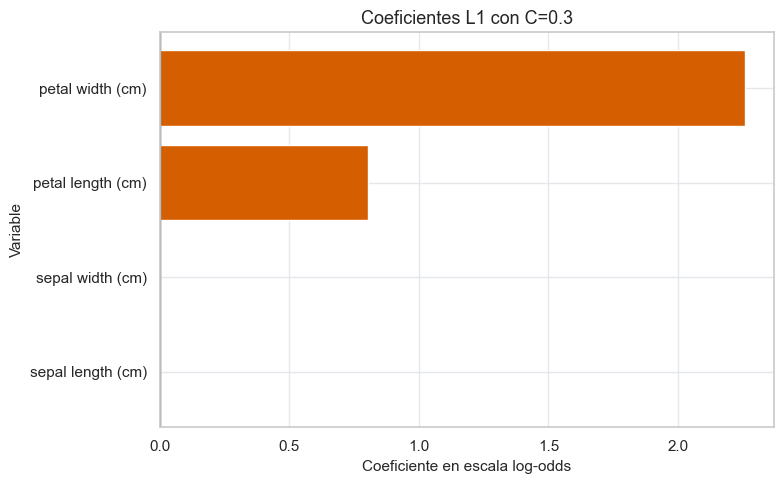

In [5]:
# C=0.3 es un punto intermedio: muestra selección sin convertir el ejemplo en un extremo.
# liblinear y max_iter=5000 mantienen la comparación consistente con la ruta L1 anterior.
representative_l1 = LogisticRegression(
    penalty="l1",
    C=0.3,
    solver="liblinear",
    max_iter=5000,
    random_state=RANDOM_STATE,
)
representative_l1.fit(X_train_scaled, y_train)
plot_coefficients(representative_l1.coef_.ravel(), feature_names, "Coeficientes L1 con C=0.3")
plt.show()


**Interpretación.** Los coeficientes cero indican variables descartadas por el penalti. Hastie, Tibshirani & Friedman (2009) contrastan esta propiedad con L2: Ridge encoge, Lasso encoge y selecciona.


## 5. Frontera de decisión L1 en 2D

Aquí sí usamos la palabra `sparse`, porque L1 puede apagar coeficientes exactamente. Para que texto y figuras hablen el mismo idioma, cada título combina fuerza de regularización y sparsity: `C=0.1` es regularización fuerte/más sparse; `C=10.0` es regularización débil/menos sparse.


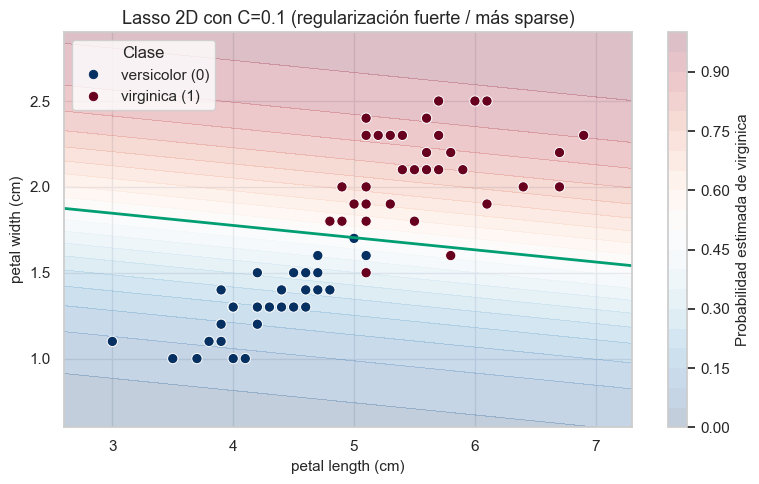

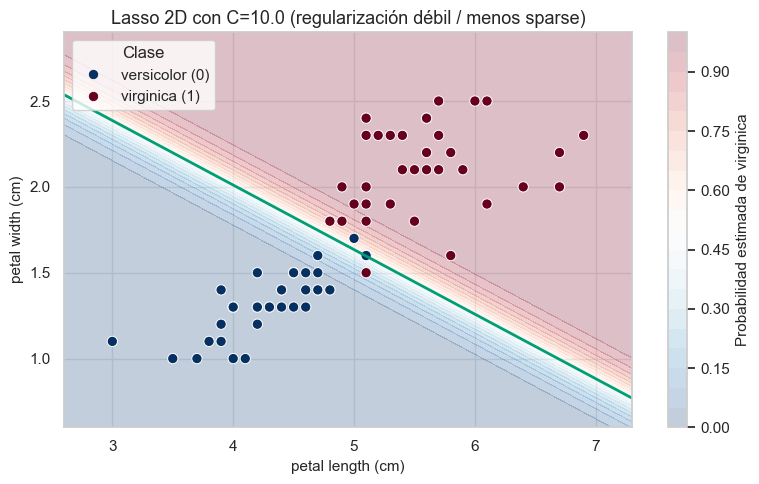

In [6]:
# Usamos modelos 2D auxiliares para ver cómo la sparsity cambia la frontera.
# C=0.1 => regularización fuerte y más ceros; C=10.0 => regularización débil y menos ceros.
# Conservamos liblinear y max_iter=5000 para que la comparación visual aísle el efecto de C.
features_2d = ["petal length (cm)", "petal width (cm)"]
lasso_boundary_settings = [
    (0.1, "regularización fuerte / más sparse"),
    (10.0, "regularización débil / menos sparse"),
]
for C, label in lasso_boundary_settings:
    model_2d = make_pipeline(
        StandardScaler(),
        LogisticRegression(penalty="l1", C=C, solver="liblinear", max_iter=5000, random_state=RANDOM_STATE),
    )
    model_2d.fit(X_train[features_2d], y_train)
    plot_decision_boundary(
        model_2d,
        X_train[features_2d],
        y_train,
        features_2d,
        f"Lasso 2D con C={C} ({label})",
    )
    plt.show()


**Interpretación.** La etiqueta `regularización fuerte / más sparse` indica que `C` pequeño aumenta la penalización L1 y puede dejar menos variables activas. La etiqueta `regularización débil / menos sparse` indica que `C` grande reduce la penalización y permite una frontera más parecida a la logística no penalizada.


## Resumen y conexion con la literatura

Tibshirani (1996) introdujo el Lasso como una forma de hacer encogimiento y selección de variables en una sola estimación. Hastie, Tibshirani & Friedman (2009) explican que la geometría de la penalización L1 es la responsable de los coeficientes exactamente cero, propiedad que observamos en la ruta y en la tabla de variables sobrevivientes.
